In [1]:
import torch
#!pip install tiingo

## 1. Data Collection

In [2]:
from tiingo import TiingoClient
import pandas as pd

api_key = '0c25216af7136c18af06513f756202043aed2e2c'

# Set up the Tiingo API client
config = {
    'api_key': api_key
}
client = TiingoClient(config)
data = client.get_dataframe('MSFT', startDate='2000-01-01', endDate='2024-12-30')

# Save the data to a CSV file
data.to_csv("MSFT_historical_data.csv")
print(data.head())


                            close    high     low    open    volume  \
date                                                                  
2000-01-03 00:00:00+00:00  116.56  118.62  112.00  117.37  26614200   
2000-01-04 00:00:00+00:00  112.62  117.12  112.25  113.56  27059500   
2000-01-05 00:00:00+00:00  113.81  116.37  109.37  111.12  32029800   
2000-01-06 00:00:00+00:00  110.00  113.87  108.37  112.19  27488300   
2000-01-07 00:00:00+00:00  111.44  112.25  107.31  108.62  31006800   

                            adjClose    adjHigh     adjLow    adjOpen  \
date                                                                    
2000-01-03 00:00:00+00:00  35.939346  36.574513  34.533346  36.189097   
2000-01-04 00:00:00+00:00  34.724513  36.112013  34.610429  35.014346   
2000-01-05 00:00:00+00:00  35.091430  35.880763  33.722429  34.262013   
2000-01-06 00:00:00+00:00  33.916679  35.109930  33.414096  34.591929   
2000-01-07 00:00:00+00:00  34.360679  34.610429  33.087262  33.4

In [3]:
import pandas as pd
df = pd.read_csv("/Users/shalini/Downloads/MSFT_historical_data.csv")
print(df)

                           date   close    high     low    open    volume  \
0     2000-01-03 00:00:00+00:00  116.56  118.62  112.00  117.37  26614200   
1     2000-01-04 00:00:00+00:00  112.62  117.12  112.25  113.56  27059500   
2     2000-01-05 00:00:00+00:00  113.81  116.37  109.37  111.12  32029800   
3     2000-01-06 00:00:00+00:00  110.00  113.87  108.37  112.19  27488300   
4     2000-01-07 00:00:00+00:00  111.44  112.25  107.31  108.62  31006800   
...                         ...     ...     ...     ...     ...       ...   
6283  2024-12-23 00:00:00+00:00  435.25  437.65  432.83  436.74  19152519   
6284  2024-12-24 00:00:00+00:00  439.33  439.60  434.19  434.65   7164543   
6285  2024-12-26 00:00:00+00:00  438.11  440.94  436.63  439.08   8199927   
6286  2024-12-27 00:00:00+00:00  430.53  435.22  426.35  434.60  18117713   
6287  2024-12-30 00:00:00+00:00  424.83  427.55  421.90  426.06  13158703   

        adjClose     adjHigh      adjLow     adjOpen  adjVolume  divCash  \

## 2. Data Preprocessing

In [4]:
df = df.drop(columns=['high', 'low',  'open','volume', 'adjClose', 'adjHigh', 'adjLow' ,'adjOpen', 'adjVolume', 'divCash', 'splitFactor'])
data = df.close.values
print(len(data))
max(df.close)
data

6288


array([116.56, 112.62, 113.81, ..., 438.11, 430.53, 424.83])

In [5]:
df['date'] = pd.to_datetime(df['date']).dt.date
print(df)

            date   close
0     2000-01-03  116.56
1     2000-01-04  112.62
2     2000-01-05  113.81
3     2000-01-06  110.00
4     2000-01-07  111.44
...          ...     ...
6283  2024-12-23  435.25
6284  2024-12-24  439.33
6285  2024-12-26  438.11
6286  2024-12-27  430.53
6287  2024-12-30  424.83

[6288 rows x 2 columns]


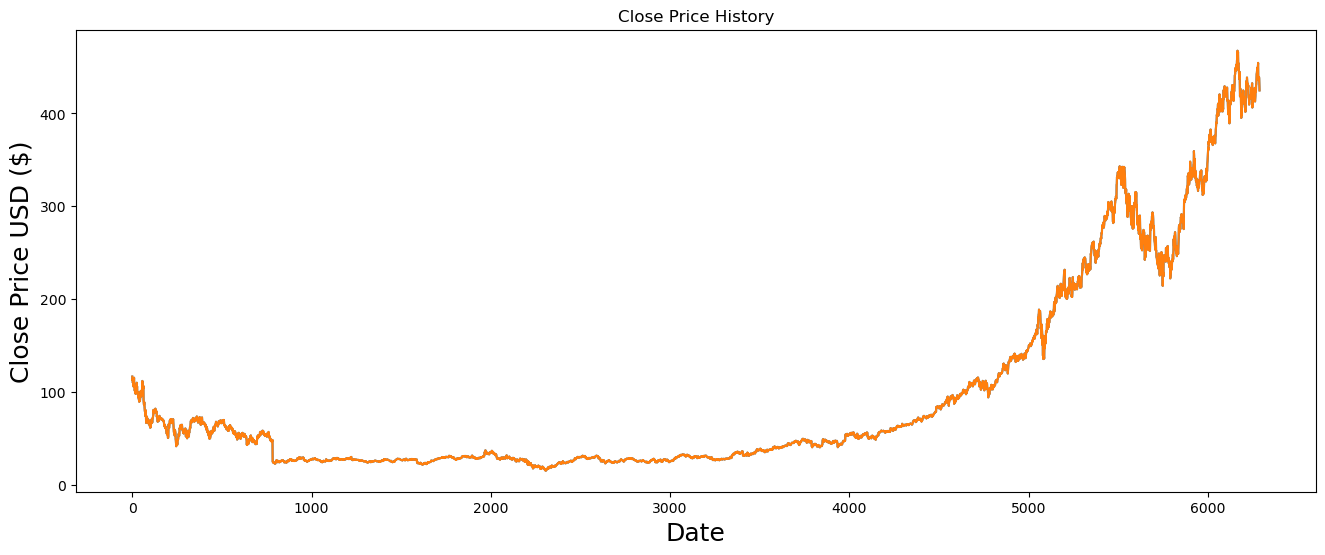

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.plot(df.index, df['close'])
plt.title('Close Price History')
plt.plot(df['close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [7]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device
len(df)

6288

In [8]:
## 3. Feature Engineering

In [9]:
from copy import deepcopy as dc

df = df[['date','close']]
df['date'] = pd.to_datetime(df['date']).dt.date
df.set_index('date', inplace=True)
df = dc(df)


laggered = 25
for i in range(laggered, 0, -1):      df[f'close(t-{i})'] = df['close'].shift(i)

df.dropna(inplace=True)
print(df)

             close  close(t-22)  close(t-21)  close(t-20)  close(t-19)  \
date                                                                     
2000-02-03  103.62       116.56       112.62       113.81       110.00   
2000-02-04  106.56       112.62       113.81       110.00       111.44   
2000-02-07  106.62       113.81       110.00       111.44       112.25   
2000-02-08  109.94       110.00       111.44       112.25       109.37   
2000-02-09  104.00       111.44       112.25       109.37       105.81   
...            ...          ...          ...          ...          ...   
2024-12-23  435.25       415.49       412.87       417.00       418.79   
2024-12-24  439.33       412.87       417.00       418.79       427.99   
2024-12-26  438.11       417.00       418.79       427.99       422.99   
2024-12-27  430.53       418.79       427.99       422.99       423.46   
2024-12-30  424.83       427.99       422.99       423.46       430.98   

            close(t-18)  close(t-17) 

In [10]:
## 4. Data Scaling

In [40]:
import numpy as np

df_as_np = df.to_numpy()
print(df_as_np.shape)

(6266, 23)


In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
df_as_np = scaler.fit_transform(df_as_np)

df_as_np


array([[-0.60889459, -0.55168984, -0.56910767, ..., -0.63431401,
        -0.61190071, -0.62131695],
       [-0.59589753, -0.56910767, -0.56384695, ..., -0.61190071,
        -0.62131695, -0.60889459],
       [-0.59563228, -0.56384695, -0.58069008, ..., -0.62131695,
        -0.60889459, -0.59589753],
       ...,
       [ 0.86980836,  0.77648593,  0.78439911, ...,  0.863133  ,
         0.85716496,  0.8752017 ],
       [ 0.83629893,  0.78439911,  0.82507018, ...,  0.85716496,
         0.8752017 ,  0.86980836],
       [ 0.81110055,  0.82507018,  0.80296634, ...,  0.8752017 ,
         0.86980836,  0.83629893]])

In [42]:
X = df_as_np[:, 1:]
y = df_as_np[:, 0]

print(y)

[-0.60889459 -0.59589753 -0.59563228 ...  0.86980836  0.83629893
  0.81110055]


In [43]:
## 5. Data Splitting 

In [80]:
# Create train/test split
train_split = int(0.90* len(X)) 
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)


(5639, 5639, 627, 627)

In [81]:
# Print the new shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5639, 22)
X_test shape: (627, 22)
y_train shape: (5639,)
y_test shape: (627,)


In [82]:

X_train = X_train.reshape((-1, laggered, 1))
X_test = X_test.reshape((-1, laggered, 1))

y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5639, 22, 1), (627, 22, 1), (5639, 1), (627, 1))

In [83]:
#!pip install torch torchvision torchaudio

import torch
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([5639, 22, 1]),
 torch.Size([627, 22, 1]),
 torch.Size([5639, 1]),
 torch.Size([627, 1]))

In [84]:
## 6. Model Creation

In [85]:
#Define and initialize LSTM.
import torch
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(1,4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [86]:
#Set up loss function and optimizer.
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [87]:
## 7. Training  and Testing 

In [88]:
torch.manual_seed(42)

# Set the number of epochs 
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model.train() 

    # 1. Forward pass
    y_pred = model(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model(X_test)
        
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.9721895456314087 | Test loss: 0.2564099431037903
Epoch: 100 | Train loss: 0.0002746874815784395 | Test loss: 0.056430526077747345
Epoch: 200 | Train loss: 0.00010768539505079389 | Test loss: 0.023417513817548752
Epoch: 300 | Train loss: 7.791085226926953e-05 | Test loss: 0.013927615247666836
Epoch: 400 | Train loss: 7.32023108866997e-05 | Test loss: 0.011027893051505089
Epoch: 500 | Train loss: 7.269978959811851e-05 | Test loss: 0.009999165311455727
Epoch: 600 | Train loss: 7.243931031553075e-05 | Test loss: 0.009409056976437569
Epoch: 700 | Train loss: 0.00023779697949066758 | Test loss: 0.009807134047150612
Epoch: 800 | Train loss: 7.339008880080655e-05 | Test loss: 0.00886959582567215
Epoch: 900 | Train loss: 7.255696255015209e-05 | Test loss: 0.008042351342737675


In [89]:

with torch.inference_mode():
    preds = model(X_train.to(device)).to('cpu').numpy()


In [90]:
# Print the new shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([5639, 22, 1])
X_test shape: torch.Size([627, 22, 1])
y_train shape: torch.Size([5639, 1])
y_test shape: torch.Size([627, 1])


In [91]:
## 8 Plot actual vs predicted values for Train and Test data

In [92]:
import numpy as np
train_predictions = preds.flatten()

dummies = np.zeros((X_train.shape[0], laggered+1))

dummies[:, 0] = train_predictions

dummies = scaler.inverse_transform(dummies)

train_predictions = dc(dummies[:, 0])
train_predictions

array([111.84123315, 113.01902914, 116.50952812, ..., 264.80200524,
       265.42302617, 263.61061852])

In [93]:
dummies = np.zeros((X_train.shape[0], laggered+1))
dummies[:, 0] = y_train.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_train = dc(dummies[:, 0])
new_y_train

array([103.62000005, 106.55999349, 106.62000574, ..., 260.25999925,
       256.8299996 , 259.5799992 ])

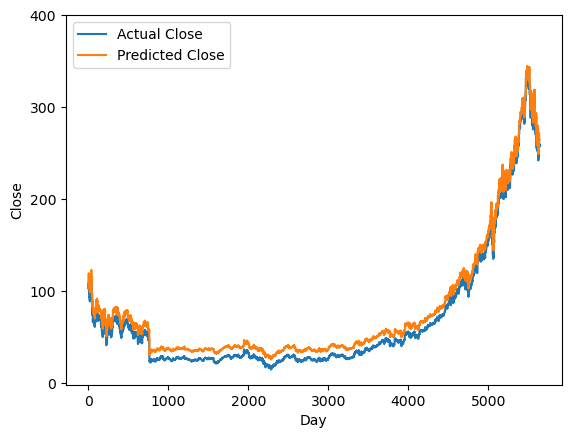

In [94]:
import matplotlib.pyplot as plt

# Plotting the actual and predicted close values
plt.plot(new_y_train, label='Actual Close')
plt.plot(train_predictions, label='Predicted Close')

plt.xlabel('Day')
plt.ylabel('Close')
plt.yticks(range(0, int(max(max(new_y_train), max(train_predictions))) + 100, 100))
plt.legend()
plt.show()

In [95]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies = np.zeros((X_test.shape[0], laggered + 1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = dc(dummies[:, 0])

In [96]:
dummies = np.zeros((X_test.shape[0], laggered+1))
dummies[:, 0] = y_test.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_test = dc(dummies[:, 0])
#new_y_test

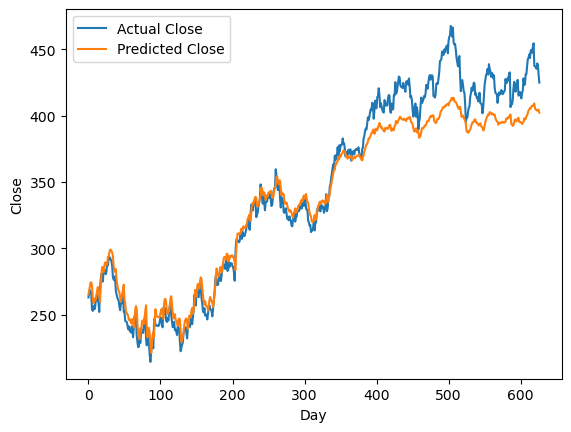

In [97]:
plt.plot(new_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [34]:
## 9. Prediction for next 2 days

In [35]:
def pre(arr,value):
    n = len(arr[0]) - 1
    for i in range(n):
        arr[0][i] = arr[0][i+1]

    arr[0][n] = value
    return arr


In [37]:
from sklearn.preprocessing import MinMaxScaler

def func(arrr,laggered):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    arr = scaler.fit_transform(arrr)

    tensor = torch.tensor(arr, dtype=torch.float32)
    tensor = tensor.reshape(1,laggered,1)
    with torch.inference_mode():
        preds = model(tensor.to(device)).to('cpu').numpy()
    train_predictions = preds.flatten()
    
    dummies = np.zeros((tensor.shape[0], laggered))

    dummies[:, 0] = train_predictions

    dummies = scaler.inverse_transform(dummies)

    train_predictions = dc(dummies[:, 0])
    return train_predictions[0] 

In [38]:
arr = data[(len(data) - laggered):]
arr = arr.reshape(1,-1)
p = []
next_days = 10
for i in range(next_days):
    last = func(arr,laggered)
    p.append(last)
    pre(arr,last)
rounded_p = [round(x, 2) for x in p]  
print(rounded_p)

[422.99, 423.46, 430.98, 431.2, 437.42, 442.62, 443.57, 446.02, 443.33, 448.99]


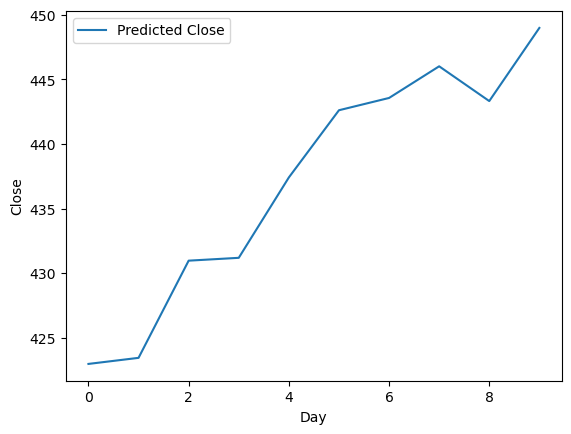

In [98]:
plt.plot(rounded_p, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()
